# SPX Local Volatility and Delta Hedging

This project studies whether a fitted local-volatility model improves SPX option
hedging relative to Black delta. It combines daily Andreasen–Huge (AH)
calibration, alternative smile-based hedge rules and an empirical
minimum-variance correction.

The analysis covers three parts:

- daily surface fits and numerical diagnostics
- historical hedge errors under consistent funding and execution assumptions
- controlled Black–Scholes and CEV simulations with known prices and Greeks

The historical study covers 2013–2023 and is still running. Its daily models and
hedge summaries are saved in separate stages, so the results below reflect the
scope shown in the loading table.

### Saved Results

The paths in the next cell point to the existing historical and simulation
outputs. This notebook reads those outputs without starting a new run. Rerunning
the loading cell refreshes the saved-date counts and, when an active run is
found, estimates the remaining daily-model time from recent completion times.
Hedge-path evaluation follows that pass and takes additional time.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from results import StudyResults, PilotResults, SimulationResults


In [2]:
# Read the original checkout while its frozen historical study runs.
ORIGINAL_REPO = Path("/Users/pranayvij/GitHub/local-vol-spx")
STUDY_FOLDER = ORIGINAL_REPO / "outputs/historical_evaluation/full_2013_2023_v1"
SIMULATION_FOLDER = ORIGINAL_REPO / "outputs/known_model_hedging/run_20261008T094732_825260Z"

# Optional: the explicit run_index.json for a completed monthly pilot.
PILOT_INDEX = None
PILOT_MONTH = "2023-10"

study = StudyResults(STUDY_FOLDER) if (STUDY_FOLDER / "run_index.json").exists() else None
simulation = SimulationResults(SIMULATION_FOLDER) if (SIMULATION_FOLDER / "frequency_summary.csv").exists() else None
pilot = PilotResults(PILOT_INDEX, PILOT_MONTH, ORIGINAL_REPO).load() if PILOT_INDEX else None

summary_audit = None
status_rows = []
if study:
    latest_date = study.dates[-1] if study.dates else "none"
    run_finished = study.index.get("status") == "execution_complete"
    total_dates = None
    calendar_file = study.folder / "calendar_support.csv"
    if calendar_file.exists():
        calendar = pd.read_csv(calendar_file, dtype={"quote_date": str})
        reference = calendar.reference_session.astype(str).str.lower().eq("true")
        total_dates = int((reference & calendar.quote_date.between(study.index["start"], study.index["end"])).sum())
    status_rows.append({"Section": "Daily decisions", "Status": "History complete" if run_finished else "Partial history", "Saved scope": f"{len(study.dates):,} of {total_dates:,} reference dates; latest {latest_date}" if total_dates else f"{len(study.dates):,} dates; latest {latest_date}"})
    if study.summary_ready:
        summary_audit = study.read_json(study.summary / "audit.json")
        summary_dates = summary_audit["processed_reference_dates"]
        summary_status = "Final summary" if run_finished and summary_dates == len(study.dates) else "Prefix summary"
        if summary_dates < len(study.dates):
            summary_status = "Earlier prefix summary"
        status_rows.append({"Section": "Historical hedge results", "Status": summary_status, "Saved scope": f"{summary_dates:,} reference dates; {summary_audit['compared_paths']:,} completed paths; {summary_audit['pending_paths']:,} pending paths"})
    else:
        status_rows.append({"Section": "Historical hedge results", "Status": "Waiting for evaluation", "Saved scope": "No aggregate summary has been written"})
    print(f"Study folder: {STUDY_FOLDER}")
    print(f"Frozen date range: {study.index['start']} to {study.index['end']}")
else:
    status_rows.append({"Section": "Historical study", "Status": "Saved study not found", "Saved scope": str(STUDY_FOLDER)})
status_rows.append({"Section": "Black-Scholes / CEV controls", "Status": "Saved results available" if simulation else "Saved results not found", "Saved scope": str(SIMULATION_FOLDER)})
status_rows.append({"Section": "Earlier monthly pilots", "Status": "Linked" if pilot else "Not linked", "Saved scope": PILOT_MONTH if pilot else "Set PILOT_INDEX to inspect an existing pilot"})
display(pd.DataFrame(status_rows))
if summary_audit and summary_audit["processed_reference_dates"] < len(study.dates):
    print("Daily decisions are ahead of these hedge summaries. The runner rewrites the aggregate tables after its daily-model pass.")

# Estimate the remaining daily-model work from recent completed cache timestamps.
if study and not run_finished and total_dates:
    lock_file = study.folder / "active.lock"
    if lock_file.exists():
        lock = study.read_json(lock_file)
        started = pd.Timestamp(lock["started_utc"])
        elapsed_hours = (pd.Timestamp.now(tz="UTC") - started).total_seconds() / 3600
        print(f"Current invocation started {started.tz_convert('Asia/Kolkata'):%d %b %H:%M %Z}; elapsed {elapsed_hours:.1f} hours.")
        remaining_dates = max(0, total_dates - len(study.dates))
        timestamps = []
        for date in study.dates[-21:]:
            cache_file = study.dated_folder(date) / "cache.json"
            if cache_file.exists() and cache_file.stat().st_mtime >= started.timestamp():
                timestamps.append(cache_file.stat().st_mtime)
        if remaining_dates == 0:
            print("All reference dates are indexed. Hedge evaluation or report writing may still be running.")
        elif len(timestamps) >= 6 and timestamps[-1] > timestamps[0]:
            seconds_per_date = (timestamps[-1] - timestamps[0]) / (len(timestamps) - 1)
            remaining_hours = remaining_dates * seconds_per_date / 3600
            print(f"Recent pace: {seconds_per_date / 60:.1f} minutes per reference date over {len(timestamps) - 1} intervals.")
            print(f"Rough remaining daily-model time: {remaining_hours:.1f} hours for {remaining_dates:,} dates.")
            print("This assumes the recent pace continues. Hedge-path evaluation afterwards is additional.")
        else:
            print("Too few new daily caches in this invocation to estimate the remaining time.")


Study folder: /Users/pranayvij/GitHub/local-vol-spx/outputs/historical_evaluation/full_2013_2023_v1
Frozen date range: 2013-01-01 to 2023-12-31


,Section,Status,Saved scope
0,Daily decisions,Partial history,"564 of 2,768 reference dates; latest 2015-03-30"
1,Historical hedge results,Earlier prefix summary,"3 reference dates; 432 completed paths; 3,276 ..."
2,Black-Scholes / CEV controls,Saved results available,/Users/pranayvij/GitHub/local-vol-spx/outputs/...
3,Earlier monthly pilots,Not linked,Set PILOT_INDEX to inspect an existing pilot


Daily decisions are ahead of these hedge summaries. The runner rewrites the aggregate tables after its daily-model pass.
Current invocation started 08 Oct 18:34 IST; elapsed 16.1 hours.
Recent pace: 2.1 minutes per reference date over 20 intervals.
Rough remaining daily-model time: 78.4 hours for 2,204 dates.
This assumes the recent pace continues. Hedge-path evaluation afterwards is additional.


## Daily Surface Calibration

The AH model is fitted to the selected quotes for each reference date. The
figures show implied volatility, total variance and recovered local volatility,
with maturity slices alongside each surface. These views show how the smile
changes across strike and time to expiry. Large local-volatility values remain
visible without capping.

The recovered local volatility is separate from the proxy parameters used in
calibration. Native AH price checks are also separate from the independent
quote-total-variance interpolation. That interpolation is unconstrained and can
retain calendar or density violations even when the native AH price checks pass.

The default date is the latest saved date. `DATE` can be set to any date listed
in the study. Unsupported comparisons appear as `n/a` in the diagnostics.


,quote_date,root,status,message,model_file,calibration_quotes,rms_half_spreads,max_half_spreads,outside_original_bands,max_price_residual_points
0,2015-03-30,UNKNOWN,fitted,NaN,0f15dc23249e_ah_surface.json,524,0.186052,1.13585,1,1.663611


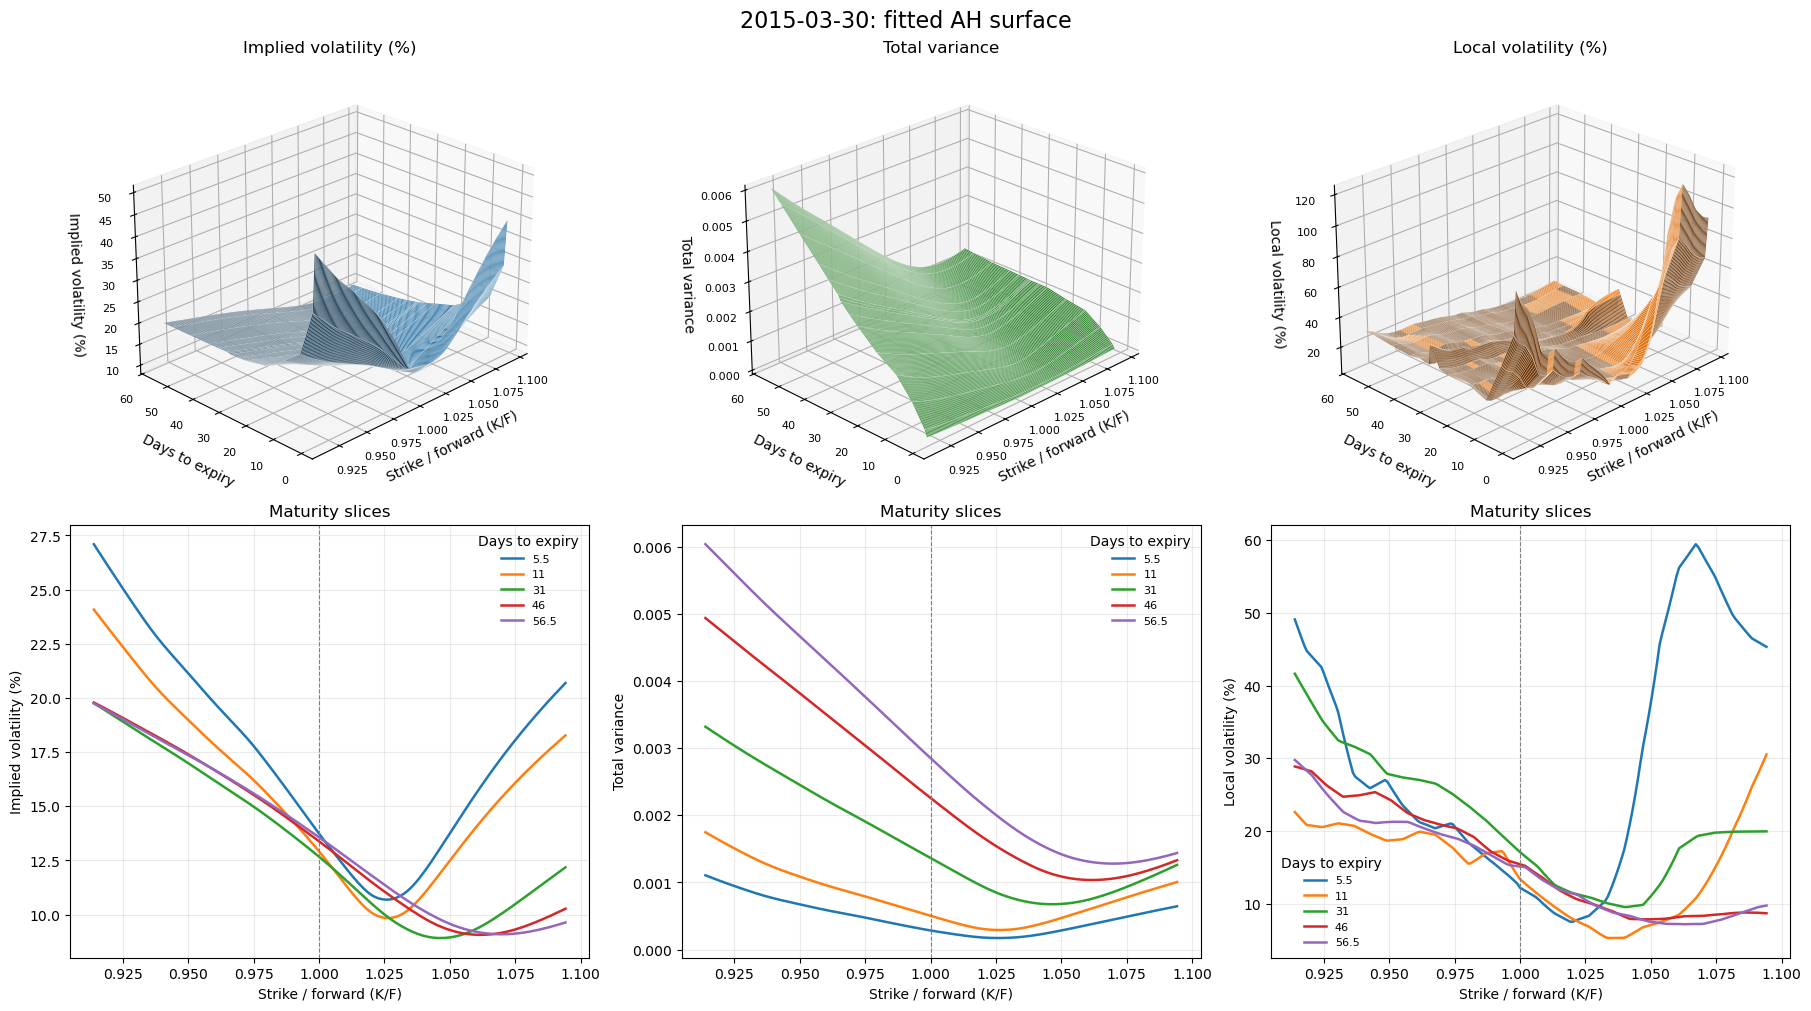

In [3]:
DATE = study.dates[-1] if study and study.dates else None
ROOT = "UNKNOWN"
evidence = None

if DATE:
    manifest = study.dated_table(DATE, "model_manifest")
    display(manifest)
    if (manifest.root.eq(ROOT) & manifest.status.eq("fitted")).any():
        evidence = study.surface_evidence(DATE, ROOT)
        samples = evidence["surface_samples"]
        samples = samples.loc[samples.side.eq("right")].copy()
        times = np.sort(samples["T"].unique())
        y = np.sort(samples["y"].unique())
        days = 365 * times
        moneyness = np.exp(y)
        X, Y = np.meshgrid(moneyness, days)
        slice_indices = np.unique([
            np.abs(days - target).argmin() for target in (7, 14, 30, 45, 60)
        ])
        fields = (
            ("ah_iv", "Implied volatility (%)", 100, "tab:blue"),
            ("ah_w", "Total variance", 1, "tab:green"),
            ("ah_actual_lv", "Local volatility (%)", 100, "tab:orange"),
        )
        fig = plt.figure(figsize=(18, 10), layout="constrained")
        fig.suptitle(f"{DATE}: fitted AH surface", fontsize=16)
        for column, (field, label, scale, color) in enumerate(fields):
            table = samples.pivot(index="T", columns="y", values=field)
            Z = scale * table.reindex(index=times, columns=y).to_numpy(float)
            Z[~np.isfinite(Z)] = np.nan

            ax = fig.add_subplot(2, 3, column + 1, projection="3d")
            ax.plot_surface(
                X, Y, Z, color=color, edgecolor="white", linewidth=0.15,
                rstride=1, cstride=1, antialiased=True, alpha=0.95,
            )
            ax.set(
                xlabel="Strike / forward (K/F)", ylabel="Days to expiry",
                zlabel=label, title=label,
            )
            ax.view_init(elev=25, azim=-135)
            ax.set_box_aspect((1.5, 1.2, 1))
            ax.tick_params(labelsize=8)

            ax2 = fig.add_subplot(2, 3, column + 4)
            for row in slice_indices:
                ax2.plot(moneyness, Z[row], linewidth=1.8, label=f"{days[row]:g}")
            ax2.axvline(1, color="grey", linestyle="--", linewidth=0.8)
            ax2.set(
                xlabel="Strike / forward (K/F)", ylabel=label,
                title="Maturity slices",
            )
            ax2.grid(alpha=0.25)
            ax2.legend(title="Days to expiry", frameon=False, fontsize=8)
        display(fig)
        plt.close(fig)
    else:
        print(f"No fitted AH surface is saved for {DATE}, root {ROOT}.")
else:
    print("No daily surface is available in the selected study.")


In [4]:
if evidence is not None:
    shape = evidence["shape_checks"]
    native = shape.loc[shape.route.eq("AH_native_full_domain")]
    independent = shape.loc[shape.route.eq("quote_total_variance")]
    display(Markdown("**Native AH Price Checks**"))
    display(native[[
        "days", "samples", "increasing_prices", "vertical_spread_violations",
        "negative_butterflies", "intrinsic_shortfalls", "upper_bound_excesses",
        "calendar_violations",
    ]])
    display(Markdown("**Independent Quote Interpolation**"))
    display(independent[[
        "days", "side", "samples", "supported", "admissible",
        "negative_calendar_derivatives", "negative_density_samples",
        "ill_conditioned_denominators", "unstable_derivative_samples",
    ]])
    display(Markdown("**Derivative Comparisons and Density Moments**"))
    display(evidence["numerical_comparison"].fillna("n/a"))
    display(evidence["density_moments"])


**Native AH Price Checks**

,days,samples,increasing_prices,vertical_spread_violations,negative_butterflies,intrinsic_shortfalls,upper_bound_excesses,calendar_violations
1,0.25,8001,0,0,0.0,0.0,0.0,0.0
3,1.00,8001,0,0,0.0,0.0,0.0,0.0
5,5.50,8001,0,0,0.0,0.0,0.0,0.0
8,11.00,8001,0,0,0.0,0.0,0.0,0.0
10,18.00,8001,0,0,0.0,0.0,0.0,0.0
13,25.00,8001,0,0,0.0,0.0,0.0,0.0
15,28.00,8001,0,0,0.0,0.0,0.0,0.0
18,31.00,8001,0,0,0.0,0.0,0.0,0.0
20,31.50,8001,0,0,0.0,0.0,0.0,0.0
23,32.00,8001,0,0,0.0,0.0,0.0,0.0


**Independent Quote Interpolation**

,days,side,samples,supported,admissible,negative_calendar_derivatives,negative_density_samples,ill_conditioned_denominators,unstable_derivative_samples
0,0.25,right,181,0.0,0.0,0.0,0.0,0.0,0.0
2,1.00,right,181,0.0,0.0,0.0,0.0,0.0,0.0
4,5.50,right,181,0.0,0.0,0.0,0.0,0.0,0.0
6,11.00,left,181,0.0,0.0,0.0,0.0,0.0,0.0
7,11.00,right,181,181.0,100.0,9.0,54.0,54.0,68.0
9,18.00,right,181,181.0,109.0,9.0,47.0,47.0,63.0
11,25.00,left,181,181.0,110.0,9.0,59.0,59.0,68.0
12,25.00,right,181,181.0,110.0,2.0,59.0,59.0,69.0
14,28.00,right,181,181.0,106.0,2.0,55.0,55.0,69.0
16,31.00,left,181,181.0,100.0,2.0,64.0,64.0,73.0


**Derivative Comparisons and Density Moments**

,quote_date,root,days,side,ah_chain_comparable,max_ah_chain_variance_difference,max_ah_fd_variance_difference,max_ah_fd_width_change,ah_fd_stable_samples,quote_supported_samples,quote_admissible_samples,max_quote_variance_difference,max_quote_price_difference
0,2015-03-30,UNKNOWN,0.25,right,181,4.427569e-13,0.006997,0.015072,181,0,0,n/a,n/a
1,2015-03-30,UNKNOWN,1.00,right,181,1.273426e-13,0.003627,0.007312,181,0,0,n/a,n/a
2,2015-03-30,UNKNOWN,5.50,right,181,4.193867e-14,0.001655,0.003063,181,0,0,n/a,n/a
3,2015-03-30,UNKNOWN,11.00,left,181,3.319567e-14,0.001207,0.002164,181,0,0,n/a,0.32344
4,2015-03-30,UNKNOWN,11.00,right,181,4.718448e-16,0.000635,0.000397,181,181,100,0.278962,0.32344
5,2015-03-30,UNKNOWN,18.00,right,181,5.981327e-15,0.000203,0.000293,181,181,109,0.262571,0.347537
6,2015-03-30,UNKNOWN,25.00,left,181,2.864375e-14,0.000432,0.000536,181,181,110,12.957509,0.111968
7,2015-03-30,UNKNOWN,25.00,right,181,9.714451e-17,0.000511,0.000371,181,181,110,15.29371,0.111968
8,2015-03-30,UNKNOWN,28.00,right,181,1.935951e-14,0.000142,0.000223,181,181,106,0.385653,0.437429
9,2015-03-30,UNKNOWN,31.00,left,181,9.006684e-15,0.000143,0.000230,181,181,100,0.5232,0.911898


,quote_date,root,days,finite_domain_nodal_mass,finite_domain_nodal_first_moment,report_window_nodal_mass,negative_nodal_densities,zero_or_underflow_nodal_densities
0,2015-03-30,UNKNOWN,0.25,1.0,1.0,1.000000,0,0
1,2015-03-30,UNKNOWN,1.00,1.0,1.0,0.999999,0,0
2,2015-03-30,UNKNOWN,5.50,1.0,1.0,0.998623,0,0
3,2015-03-30,UNKNOWN,11.00,1.0,1.0,0.992993,0,0
4,2015-03-30,UNKNOWN,18.00,1.0,1.0,0.984648,0,0
5,2015-03-30,UNKNOWN,25.00,1.0,1.0,0.973956,0,0
6,2015-03-30,UNKNOWN,28.00,1.0,1.0,0.967660,0,0
7,2015-03-30,UNKNOWN,31.00,1.0,1.0,0.961890,0,0
8,2015-03-30,UNKNOWN,31.50,1.0,1.0,0.960526,0,0
9,2015-03-30,UNKNOWN,32.00,1.0,1.0,0.959041,0,0


## Historical Hedge Performance

The default comparison holds the same option for five reference sessions and
rebalances its index hedge daily. Candidate and Black hedges use matched option
entries. Positive Gain means lower squared hedge error than Black; negative Gain
means higher squared error.

The comparison includes funding and the chosen execution scenario. Squared
errors are measured around zero, so both dispersion and mean error contribute
to Gain. The tables also report absolute errors and the number of matched
entries.

Interim hedge summaries can cover fewer dates than the daily-model cache. A
path marked `pending_run_prefix` has not reached the end of its holding period
within the saved evaluation. It becomes eligible for evaluation when a later
summary is written. Missing observations and model failures have separate
coverage statuses.


No completed matched comparisons in the saved summary for 5/1, mid.
That summary covers 3 reference dates, with 3,276 pending paths across all schedules and strategies.
Available schedules in this saved summary:


,holding_sessions,rebalance_sessions,scenario
0,1,1,mid
210,1,1,option_spread
420,1,1,option_spread_fee


Check coverage below. pending_run_prefix paths await a later evaluation; other statuses describe exclusions or failures.


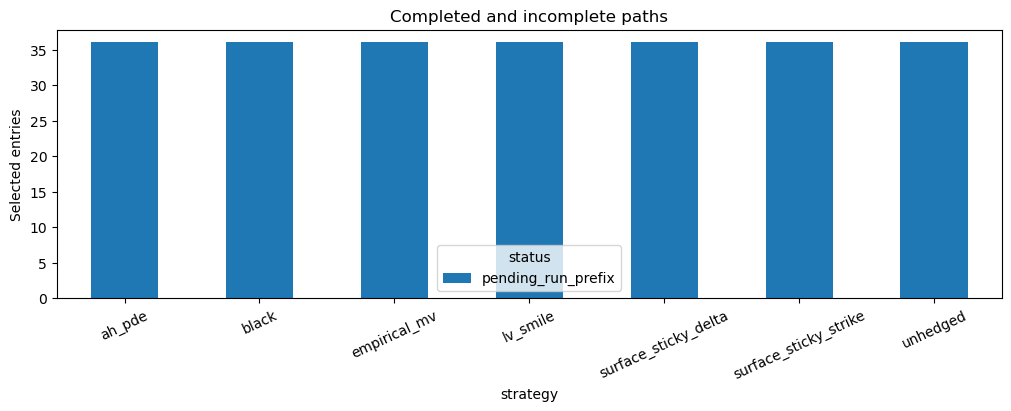

In [5]:
HOLDING = 5
REBALANCE = 1
SCENARIO = "mid"
BLOCK = 20

gains = None
selected = None
if study and study.summary_ready:
    gains = study.table("gain_summary")
    selected = gains.loc[
        gains.holding_sessions.eq(HOLDING) & gains.rebalance_sessions.eq(REBALANCE)
        & gains.scenario.eq(SCENARIO) & gains.dimension.eq("overall")
    ]
    if selected.empty:
        print(f"No completed matched comparisons in the saved summary for {HOLDING}/{REBALANCE}, {SCENARIO}.")
        if summary_audit:
            print(f"That summary covers {summary_audit['processed_reference_dates']:,} reference dates, with {summary_audit['pending_paths']:,} pending paths across all schedules and strategies.")
        if gains.empty:
            print("The saved summary contains no matched gain estimates for any schedule.")
        else:
            print("Available schedules in this saved summary:")
            display(gains[["holding_sessions", "rebalance_sessions", "scenario"]].drop_duplicates())
        print("Check coverage below. pending_run_prefix paths await a later evaluation; other statuses describe exclusions or failures.")
    else:
        display(selected)
        display(study.plot_gains(HOLDING, REBALANCE, SCENARIO, BLOCK))
    display(study.plot_coverage(HOLDING, REBALANCE, SCENARIO))
    plt.close("all")
else:
    print("Historical hedge results are waiting for the runner to write an aggregate summary.")


In [6]:
if gains is not None and selected is not None and not selected.empty:
    breakdown = gains.loc[
        gains.holding_sessions.eq(HOLDING) & gains.rebalance_sessions.eq(REBALANCE)
        & gains.scenario.eq(SCENARIO) & gains.dimension.isin(["maturity_bucket", "moneyness_bucket", "delta_bucket", "year"])
    ]
    if breakdown.empty:
        print("No bucket breakdowns are available for this saved comparison.")
    else:
        display(breakdown)
    common = study.table("common_strategy_gain")
    common = common.loc[
        common.holding_sessions.eq(HOLDING) & common.rebalance_sessions.eq(REBALANCE)
        & common.scenario.eq(SCENARIO)
    ]
    if common.empty:
        print("No common intersection of all strategies is available for this saved comparison.")
    else:
        display(common)
else:
    print("Bucket and common-strategy estimates become available when matched comparisons have been saved.")


Bucket and common-strategy estimates become available when matched comparisons have been saved.


## September and October Development Studies

The monthly pilots were used to develop and review the calibration and hedge
calculations. AH hedge performance differed between September and October, and
individual entry dates could affect the findings. These short samples informed
the broader historical evaluation.

They are development results and do not form an untouched final test set. The
full-history study is retrospective, although the rolling empirical model uses
only observations whose outcomes were available before each prediction.

Setting `PILOT_INDEX` to an existing pilot's `run_index.json` loads its saved
results. The reader checks the linked quote, carry, calibration and hedge files.


In [7]:
if pilot:
    display(pilot.frames["model_manifest"])
    display(pilot.frames["paired_results"])
    display(pilot.frames["coverage"])
    display(pilot.frames["validation_coverage"])
    display(pilot.frames["validation_sensitivity"])
else:
    print("Monthly pilot results are not linked. Set PILOT_INDEX to their saved run_index.json; no pilot rerun is needed.")


Monthly pilot results are not linked. Set PILOT_INDEX to their saved run_index.json; no pilot rerun is needed.


## Black–Scholes and CEV Simulation Controls

Black–Scholes and square-root CEV provide known prices, Greeks and exact
simulated transitions. This experiment isolates the effects of hedge frequency,
PDE approximation and account calculations from market-model mismatch.

The frequency plots compare analytical and PDE hedges, with and without fees,
on the same axes. The funded cost and mean-P&L plots show how trading costs
change the outcome as rebalancing becomes more frequent. Convergence slopes,
PDE checks and scalar-ledger comparisons are reported below the figures.


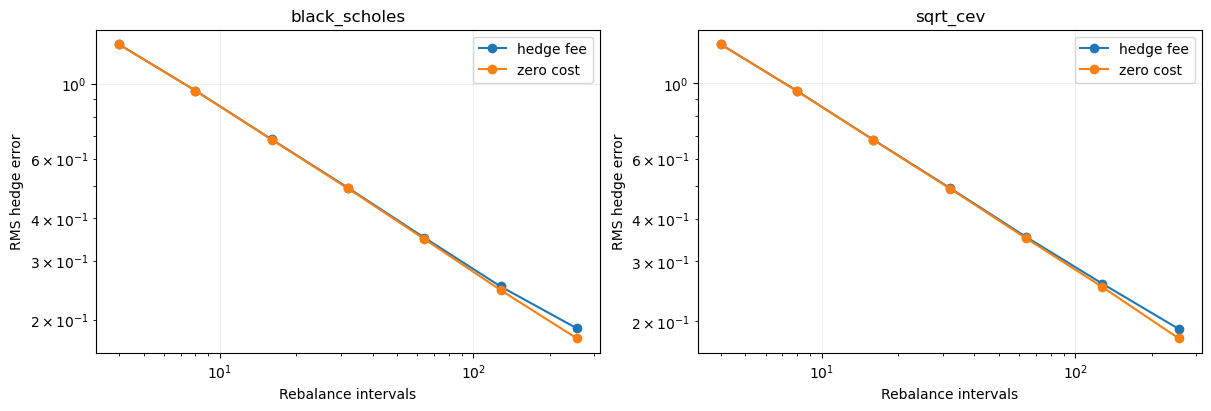

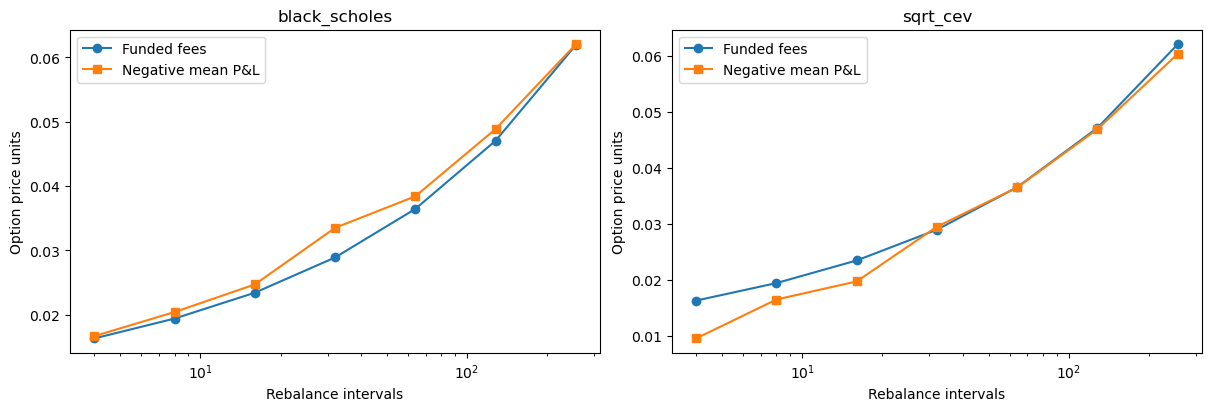

,model,strike,kind,strategy,frequencies,asymptotic_reference,status,paths,slope,slope_ci_low,slope_ci_high
0,black_scholes,95.0,call,analytical_delta,32;64;128;256,-0.5,estimated,20000,-4.846861e-01,-4.929425e-01,-4.759163e-01
1,black_scholes,95.0,call,pde_delta,32;64;128;256,-0.5,estimated,20000,-4.846865e-01,-4.936961e-01,-4.749830e-01
2,black_scholes,95.0,call,entry_iv_black,32;64;128;256,NaN,estimated,20000,-4.846861e-01,-4.937425e-01,-4.740133e-01
3,black_scholes,95.0,call,misspecified_black,32;64;128;256,NaN,estimated,20000,-2.034755e-01,-2.080884e-01,-1.986310e-01
4,black_scholes,95.0,call,unhedged,32;64;128;256,NaN,estimated,20000,1.662679e-15,1.379708e-15,2.523434e-15
5,black_scholes,100.0,call,analytical_delta,32;64;128;256,-0.5,estimated,20000,-4.928920e-01,-5.017459e-01,-4.846593e-01
6,black_scholes,100.0,call,pde_delta,32;64;128;256,-0.5,estimated,20000,-4.928834e-01,-5.000851e-01,-4.852169e-01
7,black_scholes,100.0,call,entry_iv_black,32;64;128;256,NaN,estimated,20000,-4.928920e-01,-5.005038e-01,-4.844988e-01
8,black_scholes,100.0,call,misspecified_black,32;64;128;256,NaN,estimated,20000,-2.636160e-01,-2.683569e-01,-2.592461e-01
9,black_scholes,100.0,call,unhedged,32;64;128;256,NaN,estimated,20000,1.687530e-15,1.251174e-15,1.994747e-15


,model,strike,case,calendar_time,remaining_years,time_steps,intervals,half_width,steps_per_day,control_spots,max_price_error,max_price_change_vs_base,max_delta_error,max_delta_change_vs_base,max_gamma_error,max_gamma_change_vs_base,status
0,black_scholes,95.0,base,0.000000,0.164384,2050,1600,1.0,32.0,90.0;95.0;100.0;110.00000000000001,0.000018,0.000000e+00,0.000004,0.000000e+00,0.000002,0.000000e+00,finite
1,black_scholes,95.0,base,0.082192,0.082192,2050,1600,1.0,32.0,90.0;95.0;100.0;110.00000000000001,0.000022,0.000000e+00,0.000007,0.000000e+00,0.000002,0.000000e+00,finite
2,black_scholes,95.0,base,0.163741,0.000642,2050,1600,1.0,32.0,90.0;95.0;100.0;110.00000000000001,0.000354,0.000000e+00,0.000100,0.000000e+00,0.005511,0.000000e+00,finite
3,black_scholes,95.0,space_coarse,0.000000,0.164384,2050,800,1.0,32.0,90.0;95.0;100.0;110.00000000000001,0.000134,1.298956e-04,0.000022,1.868748e-05,0.000004,2.860366e-06,finite
4,black_scholes,95.0,space_coarse,0.082192,0.082192,2050,800,1.0,32.0,90.0;95.0;100.0;110.00000000000001,0.000191,1.847416e-04,0.000046,3.912355e-05,0.000020,1.783912e-05,finite
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,sqrt_cev,105.0,time_fine,0.082192,0.082192,3956,1600,1.0,64.0,90.0;100.0;105.0;110.00000000000001,0.000024,1.457515e-07,0.000007,3.168090e-08,0.000002,9.817884e-09,finite
86,sqrt_cev,105.0,time_fine,0.163741,0.000642,3956,1600,1.0,64.0,90.0;100.0;105.0;110.00000000000001,0.000097,2.194785e-04,0.000038,6.488961e-06,0.002845,1.934577e-03,finite
87,sqrt_cev,105.0,domain_wide,0.000000,0.164384,2050,2400,1.5,32.0,90.0;100.0;105.0;110.00000000000001,0.000021,8.881784e-15,0.000003,2.320366e-14,0.000002,3.785375e-13,finite
88,sqrt_cev,105.0,domain_wide,0.082192,0.082192,2050,2400,1.5,32.0,90.0;100.0;105.0;110.00000000000001,0.000024,2.664535e-15,0.000007,3.774758e-15,0.000002,1.933731e-13,finite


,model,strike,kind,strategy,scenario,intervals,status,path_id,scalar_net_pnl,batch_net_pnl,difference,scalar_max_reconciliation,ledger_file
0,black_scholes,95.0,call,analytical_delta,zero_cost,16,verified,0,0.556328,0.556328,1.847411e-13,1.887379e-14,representative_ledgers/black_scholes_95_call_a...
1,black_scholes,95.0,call,analytical_delta,zero_cost,16,verified,1,0.049160,0.049160,2.842171e-13,2.860906e-14,representative_ledgers/black_scholes_95_call_a...
2,black_scholes,95.0,call,analytical_delta,zero_cost,16,verified,2,1.021323,1.021323,1.989520e-13,3.119727e-14,representative_ledgers/black_scholes_95_call_a...
3,black_scholes,95.0,call,analytical_delta,hedge_fee,16,verified,0,0.529195,0.529195,1.847411e-13,3.072542e-14,representative_ledgers/black_scholes_95_call_a...
4,black_scholes,95.0,call,analytical_delta,hedge_fee,16,verified,1,0.026907,0.026907,3.268497e-13,3.010266e-14,representative_ledgers/black_scholes_95_call_a...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,sqrt_cev,105.0,put,pde_delta,zero_cost,16,verified,1,0.379610,0.379610,-1.563194e-13,3.952394e-14,representative_ledgers/sqrt_cev_105_put_pde_de...
140,sqrt_cev,105.0,put,pde_delta,zero_cost,16,verified,2,0.038725,0.038725,-2.131628e-13,1.711131e-14,representative_ledgers/sqrt_cev_105_put_pde_de...
141,sqrt_cev,105.0,put,pde_delta,hedge_fee,16,verified,0,-1.316242,-1.316242,4.884981e-14,8.593820e-15,representative_ledgers/sqrt_cev_105_put_pde_de...
142,sqrt_cev,105.0,put,pde_delta,hedge_fee,16,verified,1,0.357348,0.357348,-2.131628e-13,1.978452e-14,representative_ledgers/sqrt_cev_105_put_pde_de...


In [8]:
if simulation:
    display(simulation.plot_frequency())
    display(simulation.plot_costs())
    plt.close("all")
    display(simulation.table("convergence_slopes"))
    display(simulation.table("pde_checks"))
    display(simulation.table("scalar_ledger_checks"))
else:
    print(f"No saved simulation tables were found in {SIMULATION_FOLDER}. Set the path to an existing run.")


## Interpretation and Limitations

A lower overall squared error does not establish that a hedge performs better
across all contracts or market periods. RMS error, MAE, mean P&L and coverage
describe different aspects of the result. Maturity, moneyness and year
breakdowns show where a difference is concentrated, while common-entry
comparisons account for unequal strategy coverage.

Entry-date block resampling allows for dependence from overlapping holding
periods. Sensitivity to block length and the available number of entry dates
limits how precisely a Gain estimate can be interpreted.

The synthetic index hedge, constant rates and assumed settlement clock define
the historical experiment. The results measure hedge errors under those
conventions. The [data preparation](../docs/data.md),
[methodology](../docs/methods.md), [validation](../docs/validation.md) and
[assumptions](../docs/assumptions.md) describe the inputs, calculations and their
limits. [Results and interpretation](../docs/results.md) records the completed
studies while the full-history evaluation is running.
